In [1]:

%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import geom,norm

Text(0.5, 1.0, 'Cumulative distribution of times between 100-year floods\n')

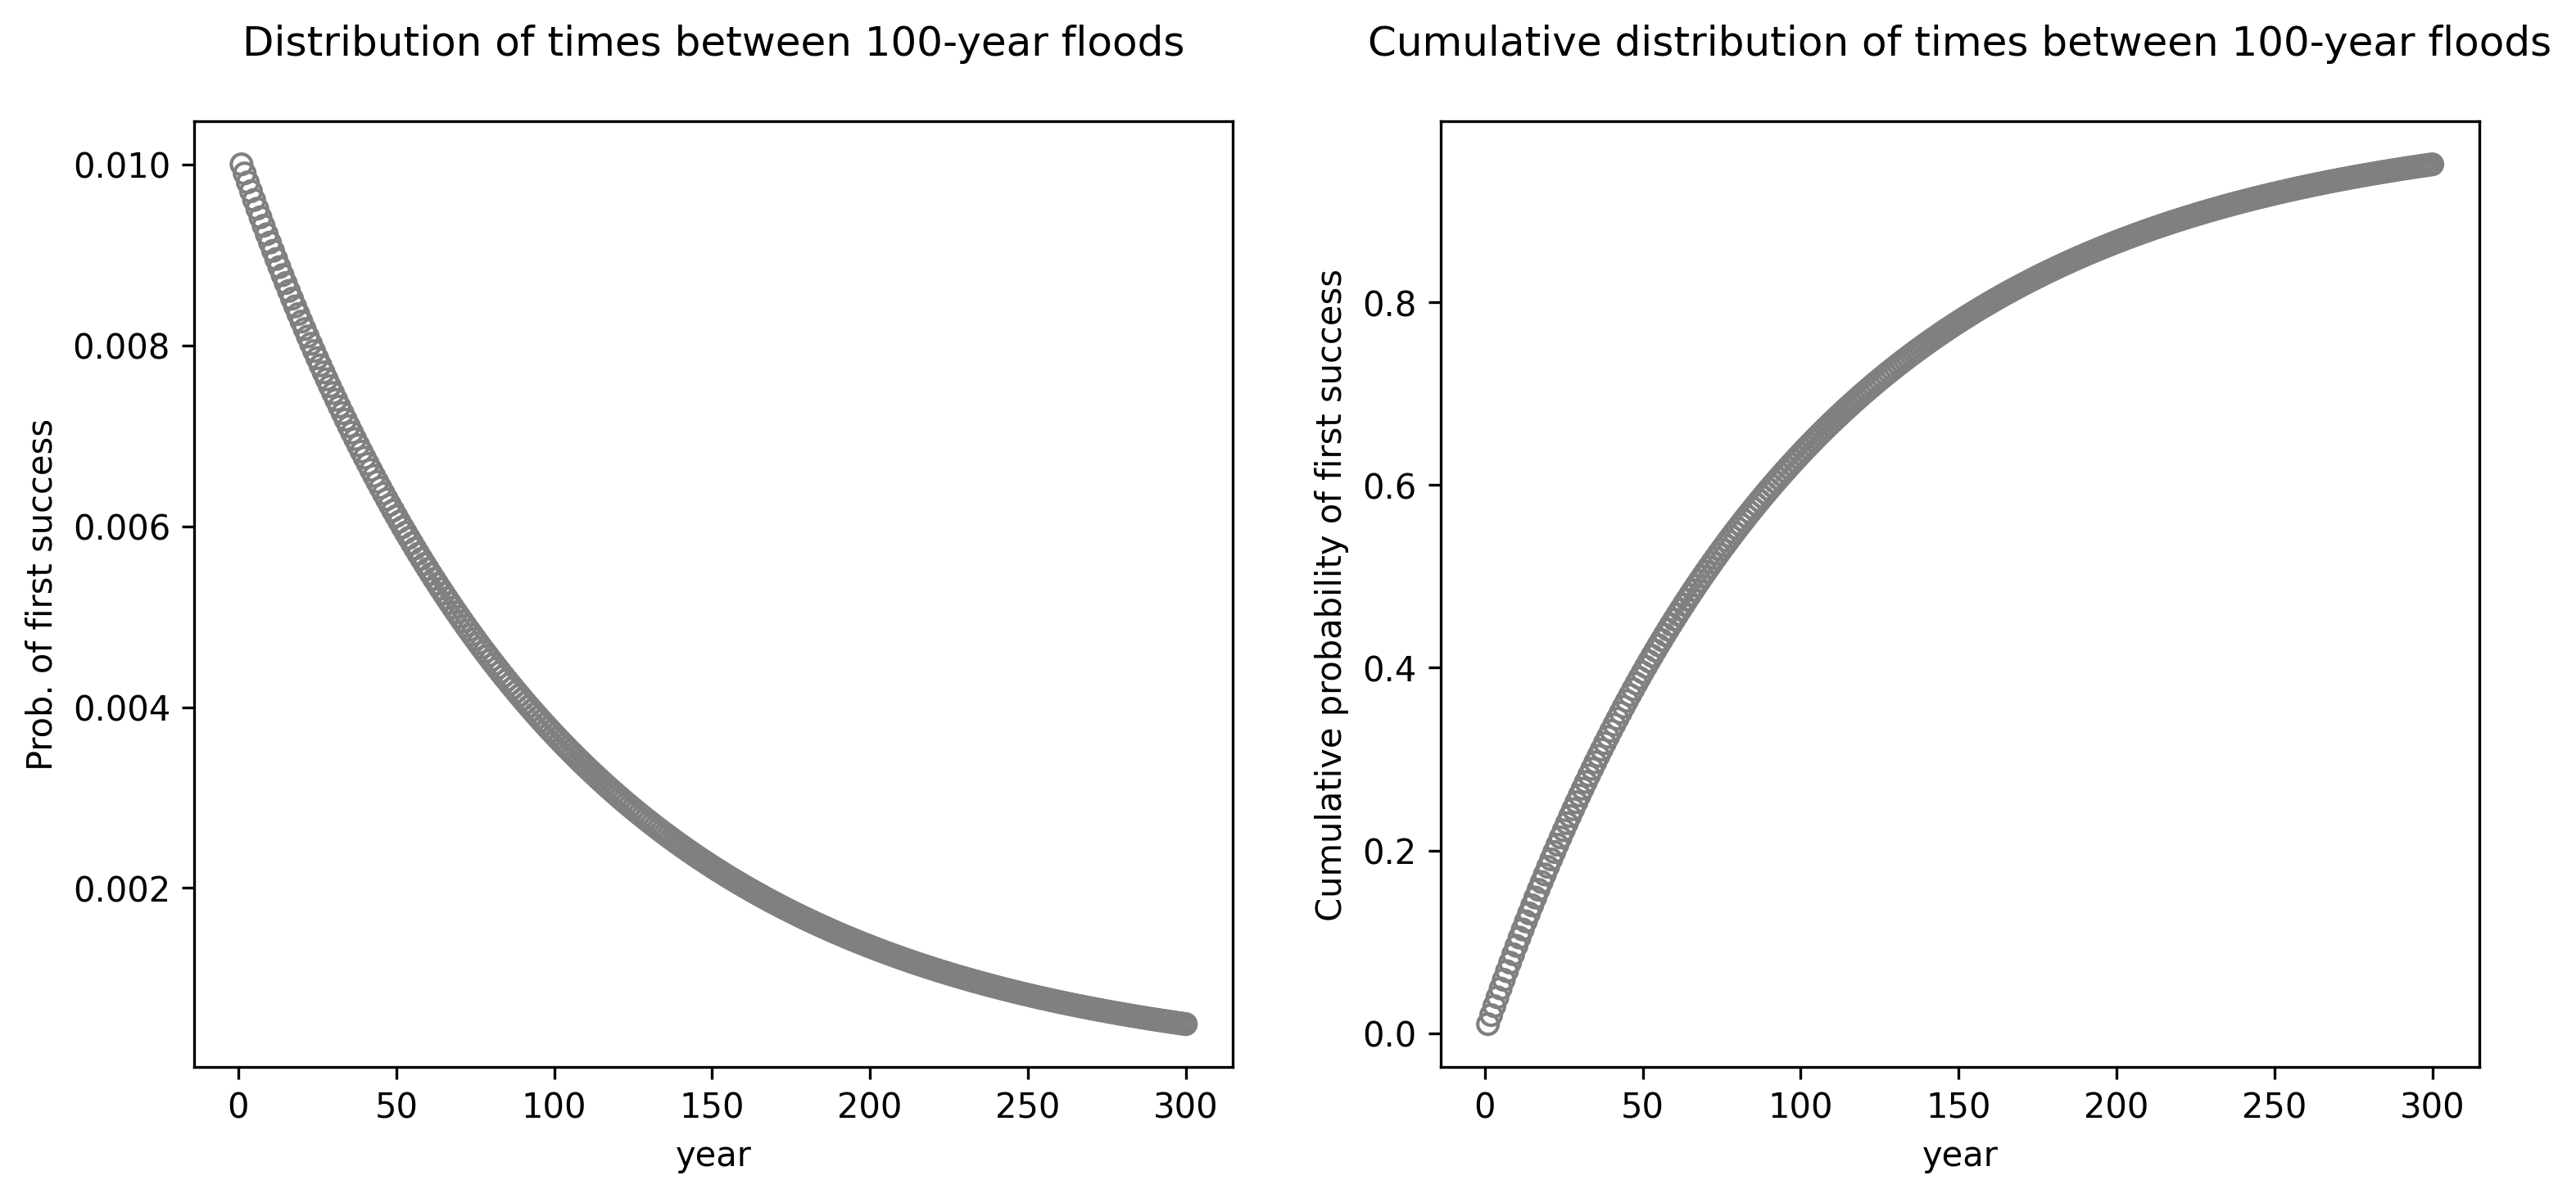

In [3]:
x = np.arange(1, 301)
y = geom.pmf(x, 0.01)
y_cdf = geom.cdf(x, 0.01)
fig,ax = plt.subplots(1,2,figsize=(12,5),dpi=300)
ax[0].scatter(x,y,facecolors='none',edgecolors='gray')
ax[0].set_xlabel("year")
ax[0].set_ylabel("Prob. of first success")
ax[0].set_title("Distribution of times between 100-year floods\n")
ax[1].scatter(x,y_cdf,facecolors='none',edgecolors='gray')
ax[1].set_xlabel("year")
ax[1].set_ylabel("Cumulative probability of first success")
ax[1].set_title("Cumulative distribution of times between 100-year floods\n")



In [4]:
geom.ppf(0.5, 0.01)

np.float64(69.0)

In [5]:
geom.ppf(0.95, 0.01)

np.float64(299.0)

In [6]:
from scipy.stats import gamma

In [7]:
lam = 1/100  # 100-year flood rate per year
T = 100      # years
k = 10       # number of events

#    Gamma CDF for time to k-th event <= T
#    SciPy gamma uses 'a' = shape = k, and 'scale' = 1/rate
p_at_least_10_gamma = gamma.cdf(T, a=k, scale=1/lam)

print("P[T_10 <= 100]      =", p_at_least_10_gamma)  # should equal P[N(100) >= 10]

P[T_10 <= 100]      = 1.1142547833872071e-07


In [8]:
gamma.cdf(100,a=2,scale=100)

np.float64(0.2642411176571153)

In [9]:
gamma.cdf(77,a=1,scale=77)

np.float64(0.6321205588285577)

In [10]:
gamma.cdf(77,a=1,scale=1000)

np.float64(0.07411014639350465)

In [11]:
from scipy.stats import beta

In [12]:
beta.cdf(0.5, a=2, b=2)

np.float64(0.5)

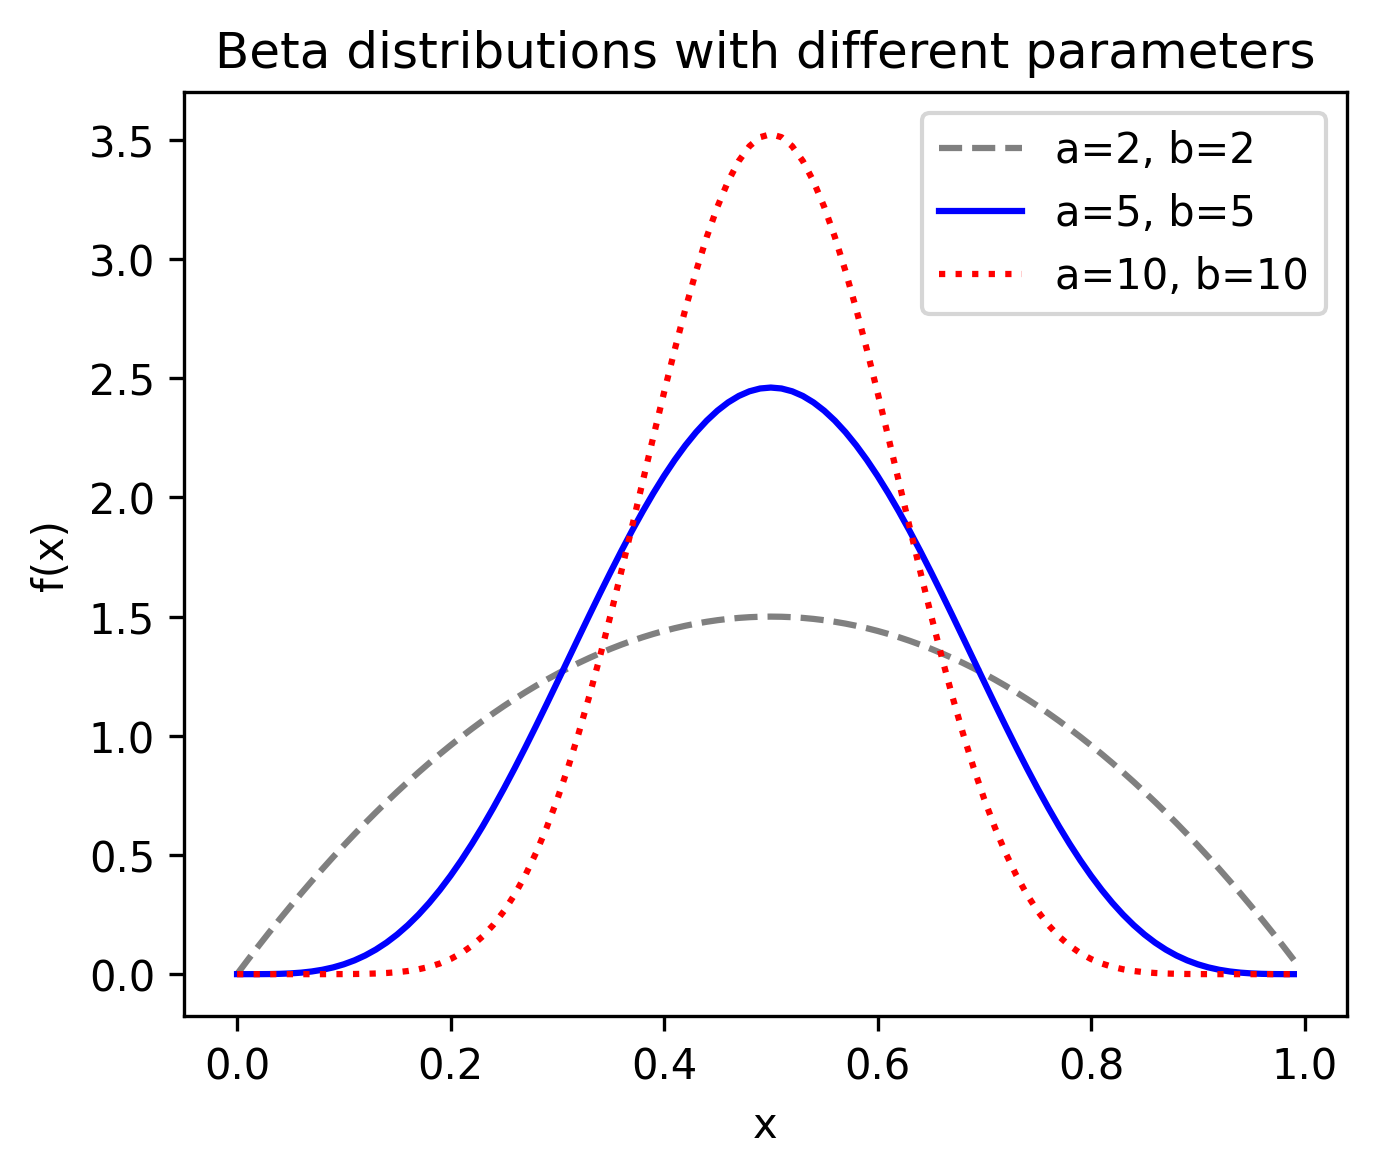

In [13]:
x = np.arange(0,1,0.01)
y1 = beta.pdf(x, a=2, b=2)
y2 = beta.pdf(x, a=5, b=5)
y3 = beta.pdf(x, a=10, b=10)

fig,ax = plt.subplots(1,1,figsize=(5,4),dpi=300)
ax.plot(x,y1,color='gray',label='a=2, b=2', ls='--')
ax.plot(x,y2,color='blue',label='a=5, b=5', ls='-')
ax.plot(x,y3,color='red',label='a=10, b=10', ls=':')
ax.set_xlabel("x")
ax.set_ylabel("f(x)")
ax.set_title("Beta distributions with different parameters")
ax.legend()

In [14]:
import numpy as np
from scipy.optimize import minimize

rng = np.random.default_rng(1)
n, d = 200, 1
X = rng.normal(size=(n, d))
beta_true = np.array([1.2])
b_true = 0.75
y = X @ beta_true + b_true + rng.normal(scale=0.2, size=n)

def mse_loss_with_intercept(theta, X, y):
    """
    theta = [beta (d params), b (1 param)]
    """
    d = X.shape[1]
    beta = theta[:d]
    b = theta[d]
    resid = X @ beta + b - y
    return np.dot(resid, resid)

theta0 = np.zeros(d + 1)  # initial guess for [beta0..., b0]

res = minimize(
    mse_loss_with_intercept,
    theta0,
    args=(X, y),
    method='Nelder-Mead',
    options={'maxiter': 5000, 'disp': True}
)

beta_hat = res.x[:d]
b_hat = res.x[d]
print("Estimated beta:", beta_hat)
print("Estimated intercept:", b_hat)
print("True beta:", beta_true, "True intercept:", b_true)

Optimization terminated successfully.
         Current function value: 6.402603
         Iterations: 66
         Function evaluations: 122
Estimated beta: [1.20800602]
Estimated intercept: 0.7324921185412689
True beta: [1.2] True intercept: 0.75


In [15]:
def gaussian_nll_from_resid(resid):
    # make sure that resid do not contain any NaN or Inf values
    r = resid
    rss = np.sum(r**2)
    sigma2_hat = rss / n  # MLE
    # -log L = n/2 * [ log(2π) + log(sigma2_hat) + 1 ]
    return 0.5 * n * (np.log(2*np.pi) + np.log(sigma2_hat) + 1.0)

# ---------- Negative log-likelihoods for each model ----------
# y = m
def nll_a(theta, x, y):
    (m,) = theta
    resid = y - m
    return gaussian_nll_from_resid(resid)

# y = m*x + b
def nll_b(theta, x, y):
    m, b = theta
    resid = y - (m * x + b)
    return gaussian_nll_from_resid(resid)

# y = a*x^2 + b*x + c
def nll_c(theta, x, y):
    a, b, c = theta
    resid = y - (a * x**2 + b * x + c)
    return gaussian_nll_from_resid(resid)

# y = a*x^3 + b*x^2 + c*x + d
def nll_d(theta, x, y):
    a, b, c, d = theta
    resid = y - (a * x**3 + b * x**2 + c * x + d)
    return gaussian_nll_from_resid(resid)

# ---------- Fitting + AIC ----------
def fit_with_aic(objfun, p0, x, y, k, method='Nelder-Mead'):
    """
    Minimizes the NLL to get MLEs and computes AIC.
    Returns: params_hat, loglike_hat, aic, scipy_result
    """
    res = minimize(objfun, x0=np.asarray(p0, float), args=(x, y), method=method)
    resid = objfun(res.x, x, y)  # residuals at the optimum
    loglike_hat = -gaussian_nll_from_resid(resid)
    aic = 2 * k - 2 * loglike_hat  # equivalent: 2*k + 2*nll_min
    return res.x, loglike_hat, aic, res

In [16]:
# Example data (replace with your real x, y arrays)
# x and y must be 1D NumPy arrays of equal length
rng = np.random.default_rng(0)
x = np.linspace(0, 20, 50)
y = 2 * x + 1 + rng.normal(0, 0.5, size=x.size)

# Model A: y = m                 (k = 1)
pa, ll_a, aic_a, resa = fit_with_aic(nll_a, p0=[20.0], x=x, y=y, k=1)

# Model B: y = m*x + b           (k = 2)
pb, ll_b, aic_b, resb = fit_with_aic(nll_b, p0=[1.0, 1.0], x=x, y=y, k=2)

# Model C: y = a*x^2 + b*x + c   (k = 3)
pc, ll_c, aic_c, resc = fit_with_aic(nll_c, p0=[1.0, 1.0, 1.0], x=x, y=y, k=3)

# Model D: y = a*x^3 + b*x^2 + c*x + d   (k = 4)
pd, ll_d, aic_d, resd = fit_with_aic(nll_d, p0=[1.0, 1.0, 1.0, 1.0], x=x, y=y, k=4)

# Collect AIC values like your R code
AIC_vals = np.array([aic_a, aic_b, aic_c, aic_d])

# ΔAIC (deviance from the best AIC)
AIC_dev = AIC_vals - np.min(AIC_vals)

# Akaike weights
AIC_wt = np.exp(-0.5 * AIC_dev)

# Relative Akaike weights
AIC_rel_wt = AIC_wt / np.sum(AIC_wt)

# Print results
print("Parameter estimates:")
print(f"A (y=m):            {pa}")
print(f"B (y=m*x+b):        {pb}")
print(f"C (quad):           {pc}")
print(f"D (cubic):          {pd}\n")

print("AIC values:", AIC_vals)
print("ΔAIC:      ", AIC_dev)
print("Akaike wts:", AIC_wt)
print("Rel. wts:  ", AIC_rel_wt)

Parameter estimates:
A (y=m):            [21.06451416]
B (y=m*x+b):        [2.02900942 0.77441596]
C (quad):           [0.00531486 1.92271221 1.12146817]
D (cubic):          [ 5.52984548e-04 -1.27843292e-02  2.08881137e+00  7.57471642e-01]

AIC values: [2095.40364908  833.84403639 1025.49056639  975.28117026]
ΔAIC:       [1261.55961269    0.          191.64653     141.43713387]
Akaike wts: [1.13713181e-274 1.00000000e+000 2.42373298e-042 1.93783418e-031]
Rel. wts:   [1.13713181e-274 1.00000000e+000 2.42373298e-042 1.93783418e-031]


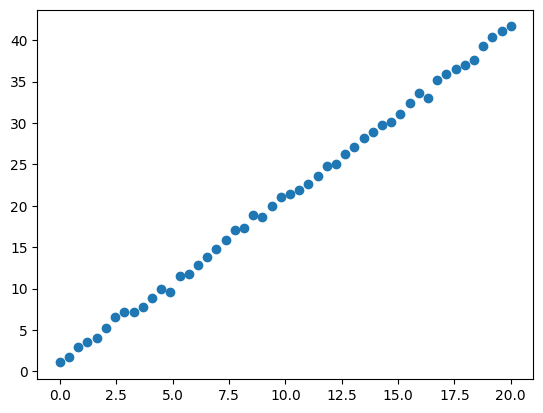

In [17]:
plt.scatter(x,y)